In [1]:
# импортирую все библиотеки, что потенциально могут понадобиться
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')
import plotly
import plotly.express as px
import seaborn as sns

In [2]:
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop(['RowNumber'], axis=1)
churn_data.head(1)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1


Столбцы таблицы:

* RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
* CustomerId — идентификатор клиента
* Surname — фамилия клиента
* CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
* Geography — страна клиента (банк международный)
* Gender — пол клиента
* Age — возраст клиента
* Tenure — сколько лет клиент пользуется услугами банка
* Balance — баланс на счетах клиента в банке
* NumOfProducts — количество услуг банка, которые приобрёл клиент
* HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
* IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
* EstimatedSalary — предполагаемая заработная плата клиента
* Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

Задача: **установить, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов**

In [3]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


* Итого имеем 3 категориальных признака - ['Surname','Geography','Gender']
* Пропусков в таблице нет

***9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.***

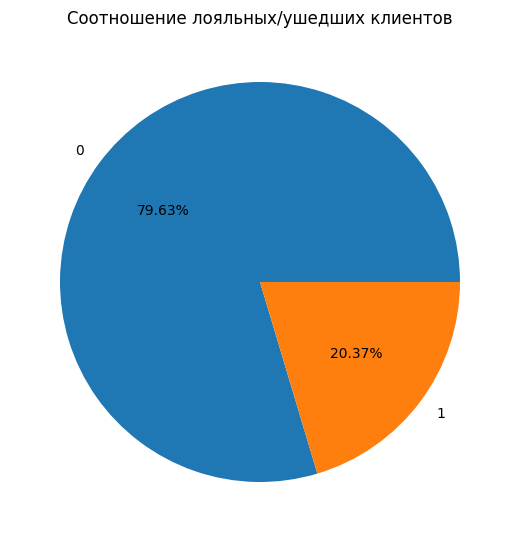

In [4]:
exited_status = churn_data['Exited'].value_counts()

fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.set_title('Соотношение лояльных/ушедших клиентов', fontsize=12)
axes.pie(
    exited_status,
    labels=exited_status.index,
    autopct='%.2f%%',
    
);

*Обоснование метода*.
Общее количество клиентов - 100%. Делится на 2 категории - лояльных(0) и ушедших(1). Максимально информативно показывает метод ```pie()```

*Вывод*: соотношение лояльных/ушедших клиентов - 79,63/20,37 = 3,9/1

--------

***9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.***

In [5]:
# отсортируем клиентов по уровню баланса > 2.500$
sorted_balance = churn_data[churn_data['Balance'] > 2500]
display(sorted_balance.head(5))

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1


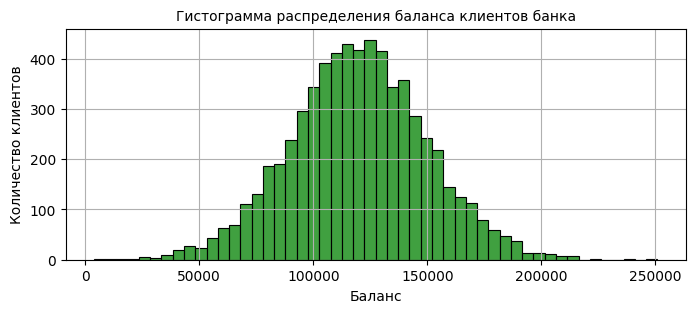

In [6]:
# Строим гистограмму
fig = plt.figure(figsize=(8, 3))
axes = sns.histplot(
    data=sorted_balance,
    x = 'Balance',
    color = 'green',
    bins=50,
    kde=False,
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Обоснование метода*. Распределение по 1 числовому признаку - гистограмма.

*Вывод*: на графике выраженный пик в диапазоне от 110.000 до 140.000. Это говорит о том, что у большинства клиентов баланс лицевого счета находится в этом диапазоне. Как видно, баланс более 200.000$ имеют единицы клиентов, как и баланс менее 30.000$

------------

***9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.***

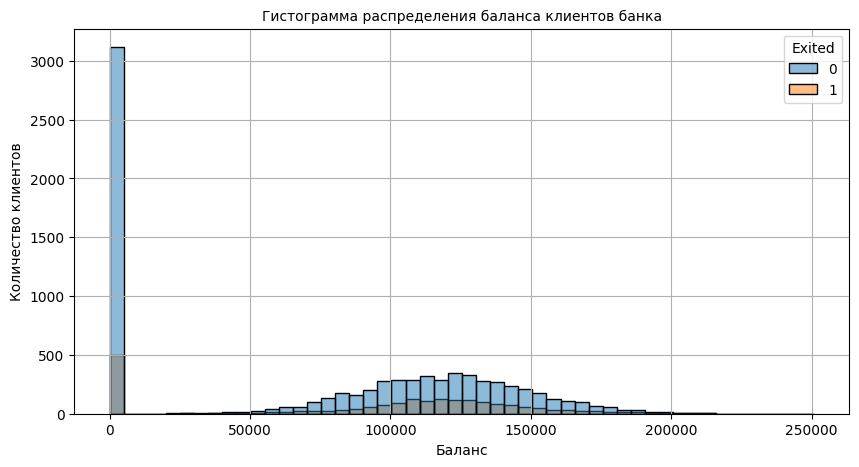

In [7]:
fig = plt.figure(figsize=(10, 5))
axes =sns.histplot(
    data=churn_data,
    x='Balance',
    bins=50,
    kde=False,
    hue = 'Exited'
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Обоснование выбора метода*. Как и в предыдущем задании, гистограмма удобна для просмотра меняющегося показателя (balance). Атрибутом ```hue``` мы добавили на ту же числовую прямую баланса второй признак - ушедших клиентов.


*Предварительный вывод*. Мы построили график для всех клиентов банка, так как в условиях не было указана фильтрация. Более, чем у 3000 лояльных клиентов на балансе нет денег. Также баланс около 0 у около 500 ушедших клиентов.
Чтобы нагляднее увидеть разницу в балансе клиентов, отфильтруем баланс от 50.000$ до 200.000$

In [8]:
sorted_balance2 = churn_data[(churn_data['Balance'] > 50000) & (churn_data['Balance'] < 200000)]

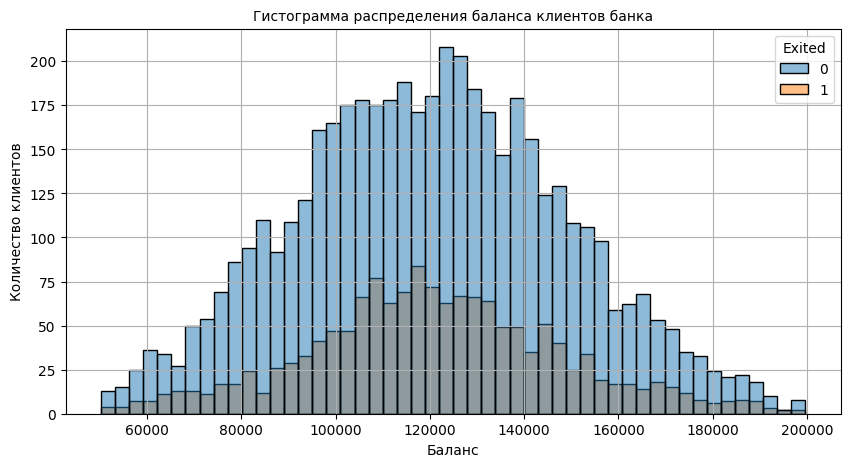

In [9]:
fig = plt.figure(figsize=(10, 5))
axes =sns.histplot(
    data=sorted_balance2,
    x='Balance',
    bins=50,
    kde=False,
    hue = 'Exited'
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Вывод*:
* Как видно из  основного распределения, баланс лояльных клиентов выше баланса ушедших в 2-3 раза.
* Для того, чтобы понять в чем причина разницы балансов, необходимо провести дополнительные исследования ушедших клиентов: их кредитный рейтинг, страну, пол, возраст и другие характеристики и поискать там закономерности.
* Что может не устраивать ушедших клиентов? Отказы по кредитам, в случае плохой кредитной истории, высокие комиссии при обслуживании, низкий сервис по сравнении с конкурентами и многое другое

------------

 ***9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?***

c:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))


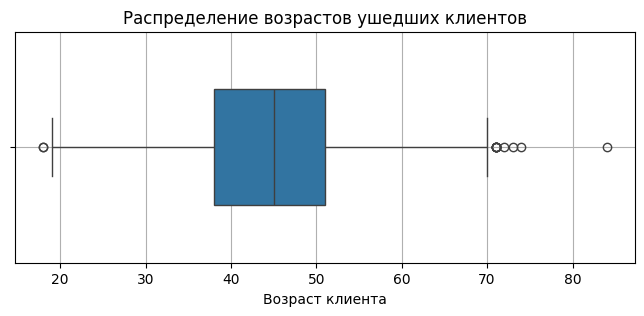

In [10]:
fig = plt.figure(figsize=(8, 3))
boxplot = sns.boxplot(
    data=churn_data[churn_data['Exited'] == 1],
    x='Age',
    orient='v',
    width=0.5
)
boxplot.set_title('Распределение возрастов ушедших клиентов');
boxplot.set_xlabel('Возраст клиента');
boxplot.grid();

*Обоснование выбора метода*: распределение числового признака в разрезе одного параметра отображается методом ```boxplot()```

*Выводы*: 
* медианное значение ушедших клиентов - 45 лет. 25 квартиль в районе 38 лет, 75 - в районе 52 лет. 
* Наблюдаются единичные выбросы в возрасте до 20 лет, а так же единичный выброс около 85 лет
* Большая часть выбросов сгруппирована от 70 до 75 лет.
* Банку стоит обратить внимание на возрастную группу 38-52 года. Большая часть ушедших клиентов состоит в ней

----------

***9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.***

In [11]:
fig = px.scatter(
    data_frame= churn_data , 
    x='CreditScore', 
    y='EstimatedSalary', 
    color= 'Exited',
    height=500, 
    width=900, 
    title='Зависимость кредитного рейтинга и предполагаемой зп' 
)
fig.show()


*Обоснование выбора метода*: взаимосвязь двух признаков в разрезе - диаграмма рассеяния. Метод ```scatter()```

*Выводы*: 
* среди лояльных клиентов нет тех, у кого кредитный рейтинг ниже 400, только у ушедших клиентов, что подтверждается отчасти причину их ухода - плохой кредитный рейтинг, отказ в кредите
* предполагаемая зарплата клиентов не выше 200 тысяч долларов
* прямой корелляции между кредитным рейтингом и зарплатой клиентов не наблюдается ни у лояльных клиентов, ни у ушедших

------------

***9.6. Кто чаще уходит, мужчины или женщины? Постройте график, который иллюстрирует это.***

*Подсказка* Процент ушедших клиентов в каждой группе можно рассчитать как среднее по столбцу Exited (так как 1 — это ушедшие клиенты, а 0 — лояльные, среднее арифметическое по столбцу обозначает долю ушедших клиентов).

In [14]:
churn_data['Gender'].value_counts(normalize=True)

Gender
Male      0.5457
Female    0.4543
Name: proportion, dtype: float64

In [12]:
#считаем средний процент ушедших клиентов
bar_data = churn_data.groupby(
    by='Gender',
    as_index=False
)[['Exited']].mean()

fig = px.bar(
    data_frame=bar_data, 
    x="Gender", 
    y="Exited", 
    color='Gender', 
    text = 'Exited', 
    orientation='v', 
    height=400, 
    width=800, 
    title='Зависимость ушедших клиентов по гендерному признаку' 
)

fig.show()

*Обоснование выбора метода*: так как в нашей задаче требуется сравнить по показателю в разрезе одного признака - я выбрал метод ```bar()```

*Выводы*:
* среди клиентов банка мужчин 55%, женщин 45%
* среди ушедших клиентов среднее значение женщин 25%, мужчин 16%

----------

***9.7. Как отток клиентов зависит от числа приобретённых у банка услуг? Для ответа на этот вопрос постройте многоуровневую столбчатую диаграмму.***

In [17]:
churn_data['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

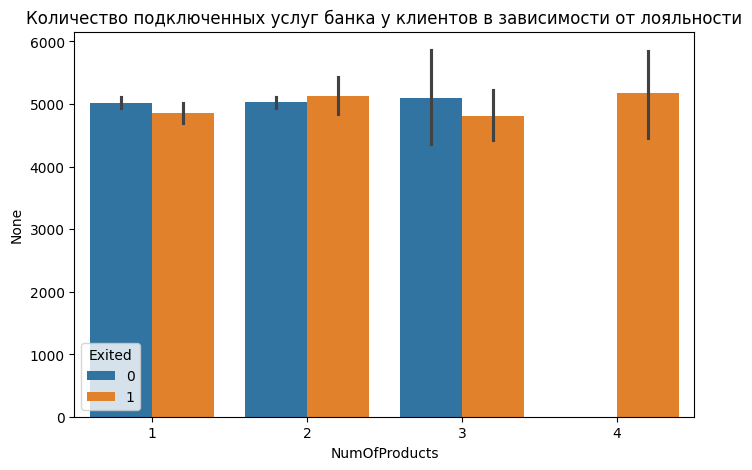

In [68]:
fig = plt.figure(figsize=(8, 5))

barplot = sns.barplot(
    data=churn_data,
    x='NumOfProducts',
    y=churn_data['NumOfProducts'].index,
    hue='Exited',
)
barplot.set_title('Количество подключенных услуг банка у клиентов в зависимости от лояльности');

*Выводы*:
* 4 услуги подключены у ушедших клиентов. Лояльных клиентов с 4 услугами нет.
* Чем больше услуг подключено у клиентов, тем выше вероятность, что он уйдет.

----------

***9.8. Как влияет наличие статуса активного клиента на отток клиентов? Постройте диаграмму, иллюстрирующую это. Что бы вы предложили банку, чтобы уменьшить отток клиентов среди неактивных?***

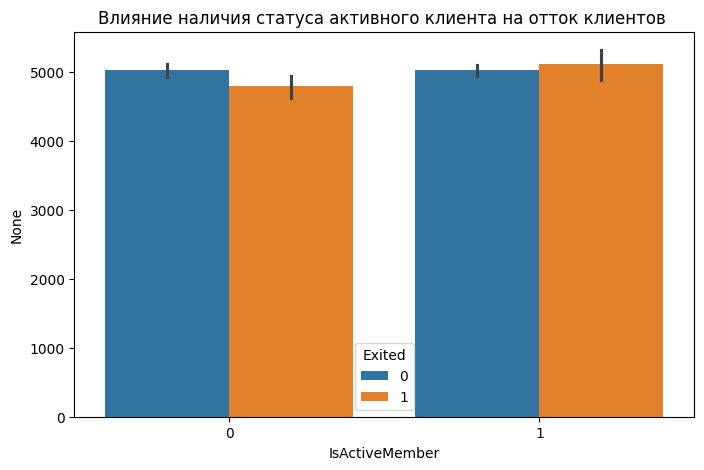

In [30]:
fig = plt.figure(figsize=(8, 5))

barplot = sns.barplot(
    data=churn_data,
    x='IsActiveMember',
    y=churn_data['IsActiveMember'].index,
    hue='Exited',
)
barplot.set_title('Влияние наличия статуса активного клиента на отток клиентов ');

*Выводы*:
* Среди неактивных клиентов отток меньше, чем у клиентов со статусом "активный клиент"
* Для уменьшения оттока клиентов среди неактивных, я бы предложил банку смс-рассылку неактивным клиентам с индивидуальными выгодными предложениями по услугам, которыми клиент пользовался ранее. Также, я бы предложил банку провести анкетирование за небольшой бонус для клиента с целью узнать, что является причиной неактивности.

----------

***9.9. В какой стране доля ушедших клиентов больше? Постройте тепловую картограмму, которая покажет это соотношение на карте мира. Предположите, с чем это может быть связано.***

In [50]:
churn_data_filtered = churn_data[(churn_data['Exited'] == 1)]
churn_data_countries = churn_data_filtered.groupby('Geography')['Exited'].count()
display(churn_data_countries)

Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

In [69]:
churn_data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [63]:
#строим график
fig = px.choropleth(
    data_frame=churn_data_filtered, #DataFrame
    locations="Geography", #столбец с локациями
    locationmode = "country names", #режим сопоставления локаций с базой Plotly
    color='Exited', #от чего зависит цвет
    title='Страны с максимальным количеством ушедших клиентов', #заголовок
    width=800, #ширина
    height=500, #высота
    color_continuous_scale='Reds' #палитра цветов
)

#отображаем график
fig.show()

C:\Users\1\AppData\Local\Temp\ipykernel_2616\4139971478.py:2: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



*Выводы*:
* Больший отток клиентов в Германии? причин предположить не могу

--------

***9.10. Переведите числовой признак CreditScore в категориальный. Для этого воспользуйтесь функцией get_credit_score_cat(), которая приведена ниже. Примените её к столбцу CreditScore и создайте новый признак CreditScoreCat — категории кредитного рейтинга.***

In [70]:
def get_credit_score_cat(credit_score):
    if credit_score >= 300 and credit_score < 500:
        return "Very_Poor"
    elif credit_score >= 500 and credit_score < 601:
        return "Poor"
    elif credit_score >= 601 and credit_score < 661:
        return "Fair"
    elif credit_score >= 661 and credit_score < 781:
        return "Good"
    elif credit_score >= 781 and credit_score < 851:
        return "Excellent"
    elif credit_score >= 851:
        return "Top"
    elif credit_score < 300:
        return "Deep"

In [76]:
CreditScoreCat = churn_data['CreditScore'].apply(get_credit_score_cat)
display(churn_data.head(2))

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,CreditScoreCat
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Fair
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Fair


***Постройте сводную таблицу, строками которой являются категории кредитного рейтинга (CreditScoreCat), а столбцами — количество лет, в течение которых клиент пользуется услугами банка (Tenure). В ячейках сводной таблицы должно находиться среднее по признаку оттока (Exited) — доля ушедших пользователей.***

In [82]:
pivot = churn_data.pivot_table(
    values='Exited',
    index='CreditScoreCat',
    columns='Tenure',
    fill_value=0
)
display(pivot)

Tenure,0,1,2,3,4,5,6,7,8,9,10
CreditScoreCat,,,,,,,,,,,
Excellent,0.275000,0.208333,0.137255,0.168317,0.131868,0.233333,0.241379,0.127660,0.196078,0.270833,0.254902
Fair,0.217391,0.215596,0.213043,0.216450,0.197248,0.206897,0.236364,0.171103,0.209016,0.190045,0.205357
Good,0.203822,0.203608,0.187342,0.205962,0.195122,0.214470,0.182857,0.191892,0.152355,0.194667,0.197802
Poor,0.226415,0.259398,0.211765,0.212245,0.233202,0.199153,0.179916,0.151261,0.214575,0.251082,0.169492
Very_Poor,0.444444,0.253731,0.151515,0.285714,0.293103,0.149254,0.225352,0.206349,0.253521,0.229508,0.333333


***На основе полученной сводной таблицы постройте тепловую карту с аннотацией. Найдите на тепловой карте категории клиентов, которые уходят чаще всего.***

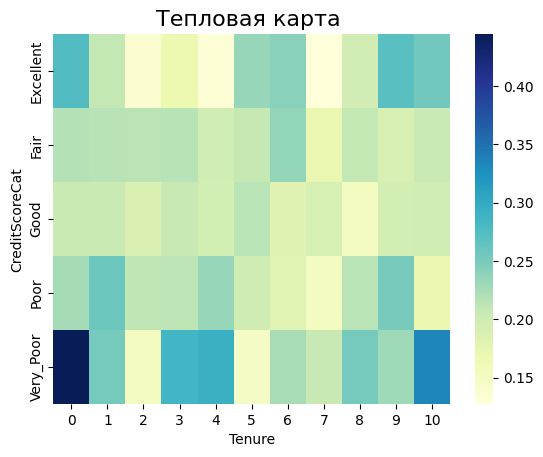

In [83]:
heatmap = sns.heatmap(data=pivot, cmap='YlGnBu')
heatmap.set_title('Тепловая карта ', fontsize=16);

*Выводы*:
* Чаще всего уходят клиенты с рейтингом 'Very_Poor' в  1 год обслуживания, 4,5 и на 11 год
* С кредитным рейтингом "Poor" клиенты уходят на 2 и 10 год обслуживания 
* Клиенты с кредитным рейтингом "Excellent" уходят в 1 год обслуживания, 6-7 и 10-11 года обслуживания